In [1]:
import pandas as pd
dataset=pd.read_csv("insurance_pre.csv")

In [2]:
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [5]:
dataset=pd.get_dummies(dataset,drop_first=True).astype(int)
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27,0,16884,0,1
1,18,33,1,1725,1,0
2,28,33,3,4449,1,0
3,33,22,0,21984,1,0
4,32,28,0,3866,1,0
...,...,...,...,...,...,...
1333,50,30,3,10600,1,0
1334,18,31,0,2205,0,0
1335,18,36,0,1629,0,0
1336,21,25,0,2007,0,0


In [6]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [7]:
independent=dataset[['age', 'bmi', 'children','sex_male', 'smoker_yes']]
independent

,age,bmi,children,sex_male,smoker_yes
0,19,27,0,0,1
1,18,33,1,1,0
2,28,33,3,1,0
3,33,22,0,1,0
4,32,28,0,1,0
...,...,...,...,...,...
1333,50,30,3,1,0
1334,18,31,0,0,0
1335,18,36,0,0,0
1336,21,25,0,0,0


In [8]:
dependent=dataset[['charges']]
dependent

,charges
0,16884
1,1725
2,4449
3,21984
4,3866
...,...
1333,10600
1334,2205
1335,1629
1336,2007


In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(independent, dependent ,test_size=0.30,random_state=0)

In [19]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='friedman_mse',splitter='best')
regressor.fit(x_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse')

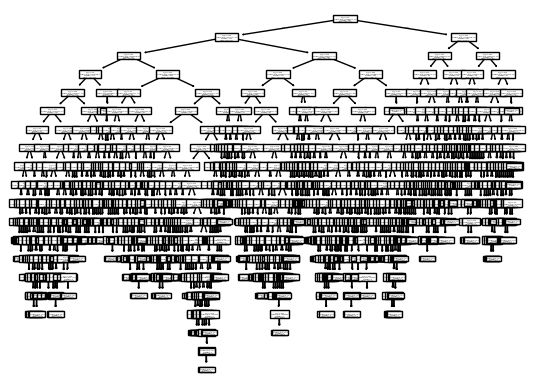

In [20]:
from sklearn import tree
tree.plot_tree(regressor)
import matplotlib.pyplot as plt
plt.show()


In [21]:
y_pred=regressor.predict(x_test)

In [22]:
y_pred

array([ 9748.        ,  8930.        , 44202.        , 13143.        ,
        9264.        , 21984.        ,  1615.        , 10848.        ,
        7144.        ,  5253.        ,  4766.        , 30284.        ,
       32108.        ,  4992.        , 20745.        , 10264.        ,
       12629.        ,  3292.        ,  6455.        , 33307.        ,
       24667.        , 10806.        ,  9625.        , 21774.        ,
        9056.        ,  4076.        ,  3161.        ,  7209.        ,
        3353.        ,  8520.        ,  7201.        , 47896.        ,
       13981.        , 10713.        , 16115.        ,  3554.        ,
        8978.        , 44585.        , 39836.        ,  1880.        ,
       21984.        ,  2866.        , 21659.        , 43921.        ,
       35585.        ,  3579.        , 10106.        ,  7046.        ,
        4719.        , 11830.        ,  2664.        ,  4296.        ,
       27218.        , 60021.        , 11856.        , 19673.        ,
      

In [23]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [24]:
r_score

0.706638349131518